## PV-Power Prediction using Physics Informed Neural Network (PINN)

1. Using Naive MLP to predict the P based on regular Data Loss
2. Integrate the physics into Loss to improve the prediction (L Thermal, L Electrical)
3. LSTM to predict the P based on the previous P based on the Loss physics 
4. Vanilla Mamba to predict the P based on the previous P based on the Data Loss only.
4. Vanilla Mamba to predict the P based on the previous P based on the Data Loss and Physics loss.


In [18]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


## Data


In [19]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------
def generate_synthetic_power_data(days=365, interval_min=15):
    """Generates synthetic power usage data."""
    # f(t) = sin(t) + 0.5sin(t/7) + noise + 10
    # noise is Gaussian noise, mean = 0, std = 0.1
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    daily = np.sin(t) 
    weekly = 0.5 * np.sin(t / 7)
    noise = np.random.normal(0, 0.1, total_steps)
    power = daily + weekly + noise + 10.0
    power = (power - power.min()) / (power.max() - power.min())
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1)



def get_station_metadata(station_num, df):
    """
    Retrieves metadata for a specific station number.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe (metaData).
        
    Returns:
        dict: A dictionary containing all processed metadata for the station.
    """
    
    # 1. Format the station ID (e.g., 5 -> 'station05')
    # zfill(2) ensures '5' becomes '05', but leaves '10' as '10'
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    # Check if station exists to prevent errors
    if station_row.empty:
        return f"Error: Station ID {station_id_str} not found."
    
    # Get the single row as a Series for easy access
    row = station_row.iloc[0]

    # --- Helper to parse the "Key:Value\nKey:Value" strings ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # 3. Parse complex columns
    module_items = parse_kv_string(row['Module'])
    inverter_items = parse_kv_string(row['Inverters'])

    # 4. Build the final dictionary
    # Note: We use .get() for the parsed items to safely handle missing keys
    result_dict = {
        'Station_ID': station_id_str, # Added ID for reference
        'Capacity': row['Capacity'],
        'pv_tech': row['PV_Technology'],
        'Panel_Size': row['Panel_Size'],
        
        # Parsed Module Items
        'Module_Pmax': module_items.get('Pmax'),
        'Module_Vmpp': module_items.get('Vmpp'),
        'Module_Impp': module_items.get('Impp'),
        
        # Parsed Inverter Items
        'Inverter_Max_DC_input': inverter_items.get('Max. DC input'),
        'Inverter_Max_DC_voltage': inverter_items.get('Max. DC voltage'),
        'Inverter_Max_DC_current': inverter_items.get('Max. DC current'),
        'Inverter_Max_DC_Rated_power': inverter_items.get('Rated power'),
        
        'Layout': row['Layout'],
        'Panel_Number': row['Panel_Number'],
        'Array_Tilt': row['Array_Tilt'],
        'Longitude': row['Longitude'],
        'Latitude': row['Latitude']
    }
    
    return result_dict


def calculate_clearsky_index(metadata, df):
    """
    Calculates Clear Sky Power (P_CLR) and PV Clear Sky Index (K_PV).
    Scales the simulation to the full station capacity and handles DataFrame outputs safely.
    """
    
    # ---------------------------------------------------------
    # 1. PARSE METADATA
    # ---------------------------------------------------------
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"Processing Station: {station_id}")
    
    def extract_num(s):
        if isinstance(s, (int, float)): return float(s)
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(s))
        return float(match.group()) if match else 0.0

    # Parse Layout
    layout_str = metadata.get('Layout', '')
    mod_per_string = 20 # default
    str_per_inv = 100   # default
    
    if 'modules per string' in layout_str:
        try:
            mod_per_string = int(extract_num(layout_str.split('modules per string:')[1].split('\n')[0]))
            str_per_inv = int(extract_num(layout_str.split('strings per inverter:')[1]))
        except:
            print("Warning: Could not parse Layout string, using defaults.")

    # Parse Tilt & Azimuth
    tilt_str = metadata.get('Array_Tilt', 'South 30')
    tilt = extract_num(tilt_str)
    
    azimuth = 180 
    if 'North' in tilt_str: azimuth = 0
    elif 'East' in tilt_str: azimuth = 90
    elif 'West' in tilt_str: azimuth = 270

    # ---------------------------------------------------------
    # 2. SETUP LOCATION & WEATHER
    # ---------------------------------------------------------
    # Copy df to avoid SettingWithCopy warnings on the original
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.set_index('date_time')
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Handle duplicates
    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep='first')]

    lat = metadata.get('Latitude', 38.0)
    lon = metadata.get('Longitude', 114.0)
    
    site_location = location.Location(lat, lon, tz='UTC') 

    print("Generating clear sky irradiance data...")
    clearsky_weather = site_location.get_clearsky(df.index, model='ineichen')

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Using PVWatts Inverter Model)
    # ---------------------------------------------------------
    temp_params = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

    # --- Module Parameters ---
    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module_template = sandia_modules.columns[0]
    module_params = sandia_modules[module_template].copy()
    
    # Overwrite electrical specs from metadata
    module_params['Impo'] = extract_num(metadata.get('Module_Impp', 8.0))
    module_params['Vmpo'] = extract_num(metadata.get('Module_Vmpp', 30.0))
    module_params['Isco'] = module_params['Impo'] * 1.05 
    module_params['Voco'] = module_params['Vmpo'] * 1.2
    
    # --- Inverter Parameters & Scaling ---
    panel_watts = extract_num(metadata.get('Module_Pmax', 300))
    
    # DC Capacity of ONE inverter block (Watts)
    block_dc_capacity_watts = (mod_per_string * str_per_inv) * panel_watts
    
    # Station Total Capacity (Watts)
    station_capacity_watts = extract_num(metadata.get('Capacity', 0)) * 1000 
    
    # Calculate Scaling Factor (How many such blocks make up the station?)
    if block_dc_capacity_watts > 0 and station_capacity_watts > 0:
        scaling_factor = station_capacity_watts / block_dc_capacity_watts
    else:
        scaling_factor = 1.0
        
    print(f"Station Capacity: {station_capacity_watts/1e6:.2f} MW")
    print(f"Modeled Block Capacity: {block_dc_capacity_watts/1e6:.2f} MW")
    print(f"Scaling Factor: {scaling_factor:.2f}x")

    inverter_params = {
        'pdc0': block_dc_capacity_watts, 
        'eta_inv_nom': 0.96 
    }

    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_params,
        modules_per_string=mod_per_string,
        strings_per_inverter=str_per_inv,
        temperature_model_parameters=temp_params
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN
    # ---------------------------------------------------------
    mc = modelchain.ModelChain(
        system, 
        site_location,
        transposition_model="perez",
        solar_position_method="nrel_numpy",
        aoi_model="physical",
        spectral_model="no_loss",
        ac_model='pvwatts'
    )

    print("Running simulation...")
    try:
        mc.run_model(clearsky_weather)
    except Exception as e:
        print(f"Simulation failed: {e}")
        return df

    # ---------------------------------------------------------
    # 5. PROCESS RESULTS (Fixing ValueError)
    # ---------------------------------------------------------
    ac_output = mc.results.ac
    
    # FIX: Ensure output is a Series, summing if it's a DataFrame
    if isinstance(ac_output, pd.DataFrame):
        ac_output = ac_output.sum(axis=1)
        
    # Scale to full station capacity
    p_clr_watts = ac_output * scaling_factor
    
    # Convert to MW
    p_clr_mw = p_clr_watts / 1_000_000
    p_clr_mw = p_clr_mw.fillna(0).clip(lower=0)
    
    # Assign to DataFrame
    df['P_CLR'] = p_clr_mw
    
    # Calculate K_PV (Clear Sky Index)
    if 'power' in df.columns:
        # Filter small P_CLR values to avoid division by zero artifacts
        df['K_PV'] = np.where(df['P_CLR'] > 0.1, df['power'] / df['P_CLR'], 0.0)
    else:
        print("Warning: 'power' column not found. K_PV not calculated.")

    return df




In [20]:
# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)


# 3. Run Calculation
station07_df = calculate_clearsky_index(station07_metaData, station07_data)

Processing Station: station07
Generating clear sky irradiance data...
Station Capacity: 20.00 MW
Modeled Block Capacity: 0.50 MW
Scaling Factor: 40.00x
Running simulation...


In [21]:
station07_df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power,P_CLR,K_PV
date_time,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,934.799988,168,0.0,0.0,0.0,0.0
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,934.700012,172,0.0,0.0,0.0,0.0
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,934.599976,174,0.0,0.0,0.0,0.0
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,934.599976,173,0.0,0.0,0.0,0.0
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,934.599976,175,0.0,0.0,0.0,0.0


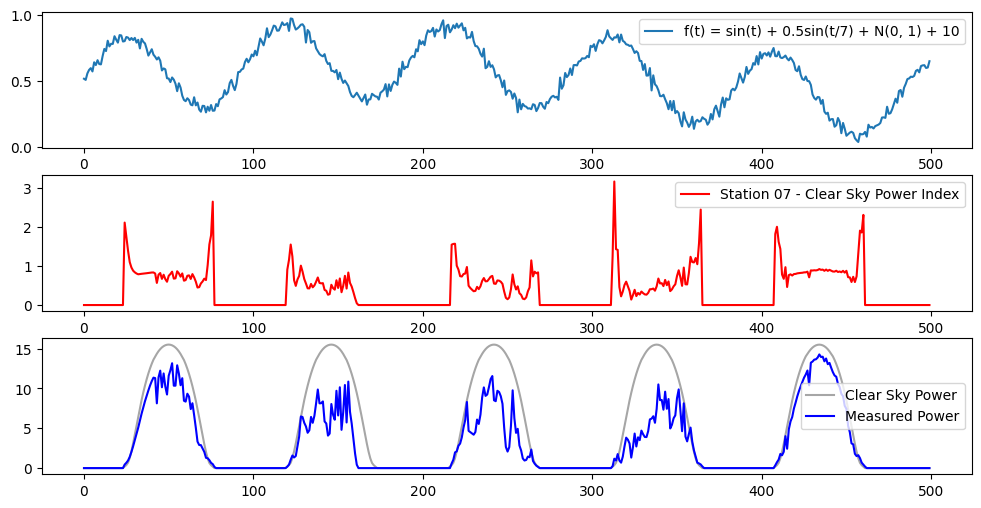

In [22]:


synthitic_power = generate_synthetic_power_data().numpy()
t = np.linspace(0, synthitic_power.shape[0], synthitic_power.shape[0])
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t[:500], synthitic_power[:500], label='f(t) = sin(t) + 0.5sin(t/7) + N(0, 1) + 10')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:500], station07_df['K_PV'][:500], label='Station 07 - Clear Sky Power Index', color='red')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:500], station07_df['P_CLR'][:500], label='Clear Sky Power', color='black', alpha=0.35)

plt.plot(t[:500], station07_df['power'][:500], label='Measured Power', color='blue')
plt.legend()

plt.show()

In [23]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)
    
    
    
    return data


station07_df = prepare_features(station07_df)




In [24]:
# ---------------------------------------------------------
# 1. Define the Dataset Class
# ---------------------------------------------------------
class MultiStepDataset(Dataset):
    """
    Multistep Dataset Preparation.
    X: Input features [Total_Samples, Num_Features] 
    y: Target to predict [Total_Samples, 1] (Power)
    """
    def __init__(self, X, y, seq_len=96, pred_len=96):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        # We need to ensure we have enough data for Input + Output
        return len(self.X) - self.seq_len - self.pred_len

    def __getitem__(self, i):
        # returning torch tensors of [i:seq_length] as input and [i+seq_length:i+seq_length+pred_len] as output
        # --- Input Sequence (Today) ---
        # Shape: [seq_len, Features] (e.g., 96, 5)
        x_seq = self.X[i : i + self.seq_len]
        
        # --- Target Sequence (Tomorrow) ---
        # We want the PV values (Column 0 usually) for the NEXT 'pred_len' steps
        # Shape: [pred_len] (e.g., 96)
        y_start = i + self.seq_len
        y_seq = self.y[y_start : y_start + self.pred_len] 
        
        return torch.tensor(x_seq), torch.tensor(y_seq)

# ---------------------------------------------------------
# 2. Preparation Function (Splitting & Scaling)
# ---------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# 2. Preparation Function (Must accept seq_len/pred_len)
# ---------------------------------------------------------
def prepare_rolling_folds(df, input_cols, target_col, n_splits=5, seq_len=96, pred_len=96, batch_size=32):
    """
    Generator that yields DataLoaders for each fold of the TimeSeriesSplit.
    Now accepts seq_len and pred_len as arguments to fix the TypeError.
    """
    X_raw = df[input_cols].values
    y_raw = df[[target_col]].values 

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold = 0
    for train_index, test_index in tscv.split(X_raw):
        fold += 1
        print(f"--- Preparing Fold {fold}/{n_splits} ---")
        
        # 1. Initial Split
        X_train_fold = X_raw[train_index]
        y_train_fold = y_raw[train_index]
        
        X_test_fold = X_raw[test_index]
        y_test_fold = y_raw[test_index]

        # 2. SCALING 
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train_fold)
        y_train_scaled = scaler_y.fit_transform(y_train_fold)

        # Transform Test
        X_test_scaled_part = scaler_X.transform(X_test_fold)
        y_test_scaled_part = scaler_y.transform(y_test_fold)

        # -------------------------------------------------------------
        # 3. Handle Lookback for Test Set
        # -------------------------------------------------------------
        # We need the last 'seq_len' from train to predict the first point of test
        train_lookback_X = X_train_scaled[-seq_len:]
        train_lookback_y = y_train_scaled[-seq_len:]

        # Concatenate: [Lookback_History] + [Actual_Test_Data]
        X_test_final = np.concatenate([train_lookback_X, X_test_scaled_part], axis=0)
        y_test_final = np.concatenate([train_lookback_y, y_test_scaled_part], axis=0)
        
        # 4. Create Datasets using the passed seq_len/pred_len
        train_dataset = MultiStepDataset(X_train_scaled, y_train_scaled, seq_len=seq_len, pred_len=pred_len)
        test_dataset = MultiStepDataset(X_test_final, y_test_final, seq_len=seq_len, pred_len=pred_len)

        # 5. Create DataLoaders
        # Shuffle=True for training helps convergence
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        yield train_loader, test_loader, scaler_X, scaler_y


import torch
import torch.nn as nn

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-2, affine=True):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        # Learnable parameters to allow the model to slightly tweak the scaling
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + 1e-10)
        x = x * self.stdev
        x = x + self.mean
        return x

    def forward(self, x, mode: str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x


In [25]:
station07_df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos'],
      dtype='object')

In [26]:

import torch
import torch.nn as nn
import numpy as np
import random

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Seq2SeqLSTM(nn.Module):
    """
    Seq2Seq LSTM for multi-step forecasting of K_PV.

    Inputs:
        x: [Batch, Seq_Len, Features] where Features = len(INPUT_COLS)
           INPUT_COLS = ['K_PV', 'nwp_globalirrad', 'nwp_temperature',
                         'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
        target: [Batch, Target_Len, 1]  (K_PV future values)
    """
    def __init__(self, input_dim, hidden_dim, output_dim, target_len, num_layers=1):
        super(Seq2SeqLSTM, self).__init__()
        self.target_len = target_len
        self.output_dim = output_dim  # should be 1 for K_PV

        # RevIN normalization over features
        self.revin = RevIN(num_features=input_dim)

        # Encoder: operates on normalized full feature vector
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        # Decoder: takes only the target feature (K_PV) as input (normalized)
        self.decoder = nn.LSTM(
            input_size=output_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, target=None, teacher_forcing_ratio=0.5):
        """
        x:      [Batch, Seq_Len, Features]
        target: [Batch, Target_Len, 1] (optional, for teacher forcing)
        Returns:
            outputs_final: [Batch, Target_Len, 1] in ORIGINAL K_PV scale
        """
        batch_size = x.size(0)

        # ==========================================
        # 1. RevIN Normalization (Input)
        # ==========================================
        # x_norm: [B, Seq_Len, F], normalized
        x_norm = self.revin(x, mode='norm')

        # ==========================================
        # 2. Encoder on normalized sequence
        # ==========================================
        # We only use final (hidden, cell) as context
        _, (hidden, cell) = self.encoder(x_norm)

        # ==========================================
        # 3. Prepare Decoder
        # ==========================================
        # Store normalized predictions
        outputs_norm = torch.zeros(batch_size, self.target_len, self.output_dim, device=device)

        # Decoder first input = last normalized target value in the encoder input
        # Target feature is index 0 in INPUT_COLS
        last_input_k_norm = x_norm[:, -1, 0].unsqueeze(-1)   # [B, 1]
        decoder_input = last_input_k_norm.unsqueeze(1)       # [B, 1, 1]

        # Precompute target normalization stats for feature 0 (K_PV)
        # RevIN saved mean/std per batch & feature during x_norm
        mean_target = self.revin.mean[:, :, 0].unsqueeze(1)  # [B, 1, 1]
        std_target = self.revin.stdev[:, :, 0].unsqueeze(1)  # [B, 1, 1]

        # ==========================================
        # 4. Decoder Loop (Autoregressive in normed space)
        # ==========================================
        for t in range(self.target_len):
            # One-step decode
            # decoder_input: [B, 1, 1]
            out, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))
            # Project to normalized K_PV
            pred_norm = self.fc(out)  # [B, 1, 1]

            # Save normalized prediction
            outputs_norm[:, t, :] = pred_norm.squeeze(1)  # [B, 1] -> [B,]

            # Teacher forcing vs autoregression
            use_teacher = (target is not None) and (random.random() < teacher_forcing_ratio)

            if use_teacher:
                # Use the true future K_PV at step t, but normalized
                real_val = target[:, t, :].unsqueeze(1)  # [B, 1, 1] in original scale
                # Normalize using same batch stats as x
                target_norm = (real_val - mean_target) / (std_target + 1e-5)
                decoder_input = target_norm  # [B, 1, 1]
            else:
                # Use own normalized prediction as next input
                decoder_input = pred_norm  # [B, 1, 1]

        # ==========================================
        # 5. Denormalize Outputs (back to original K_PV scale)
        # ==========================================
        # outputs_norm: [B, T, 1] in normalized space
        # Broadcast mean/std over time dimension
        outputs_final = outputs_norm * std_target + mean_target  # [B, T, 1]

        return outputs_final


In [27]:
class MultiStepRNN(nn.Module):
    def __init__(self, input_size, pred_len=96, hidden_size=128, n_layers=2):
        super().__init__()
        self.input_size = input_size
        self.pred_len = pred_len
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        # 1. Backbone
        self.rnn = nn.RNN(input_size, hidden_size, n_layers, batch_first=True)
        
        # 2. Projection Head (Vector Output)
        # Maps 128 hidden features -> 96 future PV values directly
        self.fc = nn.Linear(hidden_size, pred_len)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, Features]
        
        # Initialize hidden state
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Run RNN
        # out shape: [Batch, Seq_Len, Hidden_Size]
        out, _ = self.rnn(x, h0)
        
        # Slice: Take ONLY the last time step's summary
        # This summary "contains" the info for the whole past day
        last_step_out = out[:, -1, :] # Shape: [Batch, Hidden_Size]
        
        # Project: Predict the entire future vector at once
        prediction = self.fc(last_step_out) 
        # Final Shape: [Batch, Pred_Len] -> [32, 96]
        
        return prediction

In [28]:
import torch.optim as optim

def train_one_epoch(model, loader, optimizer, criterion, current_ratio):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device).float(), y_batch.to(device).float()
        
        optimizer.zero_grad()
        
        # Forward pass with Teacher Forcing
        predictions = model(X_batch, target=y_batch, teacher_forcing_ratio=current_ratio)

        
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def evaluate_fold(model, loader, criterion, scaler_y):
    """
    Evaluates model and performs Inverse Transformation to report Real-World metrics.
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_actuals = []
    losses = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device).float(), y_batch.to(device).float()
            
            # Forward pass (Teacher Forcing = 0.0 for validation!)
            predictions = model(X_batch, target=None, teacher_forcing_ratio=0.0)
            
            # Calculate Scaled Loss (for optimization monitoring)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()

            losses.append(loss.item())
            
            # Store for Inverse Scaling
            all_preds.append(predictions.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())
            
    # --- Inverse Scaling & Metric Calculation ---
    # Concatenate all batches: [Total_Samples, Pred_Len, 1]
    preds_arr = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    
    # We need to flatten to [N_points, 1] to use scaler.inverse_transform
    # Then reshape back if we want per-step metrics, but for overall RMSE flattening is fine.
    
    # Reshape to 2D for scaler
    preds_flat = preds_arr.reshape(-1, 1)
    actuals_flat = actuals_arr.reshape(-1, 1)
    
    # Inverse Transform
    preds_real = scaler_y.inverse_transform(preds_flat)
    actuals_real = scaler_y.inverse_transform(actuals_flat)
    
    # Calculate Real-World RMSE
    rmse = np.sqrt(np.mean((preds_real - actuals_real)**2))
    mae = np.mean(np.abs(preds_real - actuals_real))
    
    return total_loss / len(loader), rmse, mae, losses

In [29]:
station07_df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos'],
      dtype='object')

In [32]:
# ---------------------------------------------------------
# 3. Main Execution Loop
# ---------------------------------------------------------

# Hyperparameters


INPUT_COLS = ['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
TARGET_COL = 'K_PV'

N_SPLITS = 2
EPOCHS = 50
HIDDEN_DIM = 64
SEQ_LEN = 1344
PRED_LEN = 96
batch_size = 128


df = station07_df.copy()

import matplotlib.pyplot as plt
import numpy as np

def run_rolling_cv(df):
    results = []
    
    # Global history to store all folds
    # Structure: history[fold_num] = {'train': [], 'val': []}
    history = {} 

    # 1. Iterate through Folds
    folder_gen = prepare_rolling_folds(df, INPUT_COLS, TARGET_COL, n_splits=N_SPLITS, seq_len=SEQ_LEN, pred_len=PRED_LEN, batch_size=batch_size)
    
    for i, (train_loader, test_loader, scaler_X, scaler_y) in enumerate(folder_gen):
        fold_num = i + 1
        print(f"\n=== Training Fold {fold_num}/{N_SPLITS} ===")
        
        # Initialize history for this specific fold
        history[fold_num] = {'train': [], 'val': []}

        # 2. Instantiate FRESH Model
        input_dim = len(INPUT_COLS)

        
        # In run_rolling_cv:
        model = Seq2SeqLSTM(input_dim=len(INPUT_COLS),  # RevIN needs to know how many features
                                  hidden_dim=HIDDEN_DIM, 
                                  output_dim=1, 
                                  target_len=PRED_LEN).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        # 3. Training Loop
        for epoch in range(EPOCHS):
            # --- TRAIN ---
            current_ratio = max(0.0, 0.5 - (epoch / (EPOCHS * 0.8)))
            t_loss = train_one_epoch(model, train_loader, optimizer, criterion, current_ratio)
            
            # --- VALIDATE (Inside the loop now!) ---
            # We ignore rmse/mae here for speed, just tracking loss for the plot
            v_loss, _, _, _ = evaluate_fold(model, test_loader, criterion, scaler_y)
            
            # --- STORE ---
            history[fold_num]['train'].append(t_loss)
            history[fold_num]['val'].append(v_loss)
            
            if (epoch+1) % 5 == 0:
                print(f"... Epoch {epoch+1} | Teacher Ratio: {current_ratio:.2f} | Train: {t_loss:.4f} | Val: {v_loss:.4f}")
        
        # 4. Final Evaluation (Get Real World Metrics for Reporting)
        _, real_rmse, real_mae, _ = evaluate_fold(model, test_loader, criterion, scaler_y)
        
        print(f"--> Fold {fold_num} Finished: RMSE={real_rmse:.2f}, MAE={real_mae:.2f}")
        
        results.append({
            'fold': fold_num,
            'rmse': real_rmse,
            'mae': real_mae,
            'model': model,       # Save model to plot predictions later
            'scaler_y': scaler_y, # Save scaler to inverse transform later
            'test_loader': test_loader
        })

        # 5. Plot Loss Curve for this Fold Immediately
        plot_loss_curve(history[fold_num]['train'], history[fold_num]['val'], fold_num)

    # 6. Average Results
    avg_rmse = np.mean([r['rmse'] for r in results])
    print(f"\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")
    
    return results, history


def plot_loss_curve(train_losses, val_losses, fold_num):
    """
    Plots the Training vs Validation Loss evolution for a specific fold.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--', color='orange')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE Scaled)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_prediction_sample(model, loader, scaler_y, sample_idx=0):
    """
    Plots a single sample sequence (e.g., 1 day / 96 steps) from the test set.
    Ensures multi-step verification by plotting the full sequence.
    """
    model.eval()
    
    # 1. Get a batch of data
    # We use iter() and next() to grab the first batch
    X_batch, y_batch = next(iter(loader))
    
    # Move to device
    X_batch = X_batch.to(device).float()
    y_batch = y_batch.to(device).float()

    # 2. Predict (No Teacher Forcing - Pure Autoregression)
    with torch.no_grad():
        preds = model(X_batch, target=None, teacher_forcing_ratio=0.0)

    # 3. Pick one sample from the batch (defined by sample_idx)
    # X_batch shape: [Batch, Seq_Len, Features]
    # preds shape:   [Batch, Pred_Len, 1]
    
    # We grab the specific sample sequence
    pred_seq_scaled = preds[sample_idx].cpu().numpy()
    actual_seq_scaled = y_batch[sample_idx].cpu().numpy()
    
    # 4. Inverse Transform
    # Scaler expects 2D array [n_samples, n_features]
    # pred_seq_scaled is [96, 1], which fits perfectly
    pred_seq_real = scaler_y.inverse_transform(pred_seq_scaled)
    actual_seq_real = scaler_y.inverse_transform(actual_seq_scaled)
    
    # 5. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq_real, label='Actual (Ground Truth)', color='black', alpha=0.7)
    plt.plot(pred_seq_real, label='Predicted (Model)', color='red', linestyle='--')
    
    plt.title(f'Multi-Step Prediction Verification (Batch Index {sample_idx})')
    plt.xlabel('Time Steps (e.g., 15-min intervals)')
    plt.ylabel('Target Value (Real Scale)')
    plt.legend()
    plt.grid(True)
    plt.show()



--- Preparing Fold 1/2 ---

=== Training Fold 1/2 ===
... Epoch 5 | Teacher Ratio: 0.40 | Train: 0.3644 | Val: 0.3293
... Epoch 10 | Teacher Ratio: 0.28 | Train: 0.3431 | Val: 0.2803
... Epoch 15 | Teacher Ratio: 0.15 | Train: 0.3324 | Val: 0.2383
... Epoch 20 | Teacher Ratio: 0.03 | Train: 0.3163 | Val: 0.2562
... Epoch 25 | Teacher Ratio: 0.00 | Train: 0.3588 | Val: 0.2573
... Epoch 30 | Teacher Ratio: 0.00 | Train: 0.2838 | Val: 0.2711
... Epoch 35 | Teacher Ratio: 0.00 | Train: 0.2521 | Val: 0.2825
... Epoch 40 | Teacher Ratio: 0.00 | Train: 0.2384 | Val: 0.2721
... Epoch 45 | Teacher Ratio: 0.00 | Train: 0.2266 | Val: 0.3059
... Epoch 50 | Teacher Ratio: 0.00 | Train: 0.2283 | Val: 0.3419
--> Fold 1 Finished: RMSE=0.21, MAE=0.12


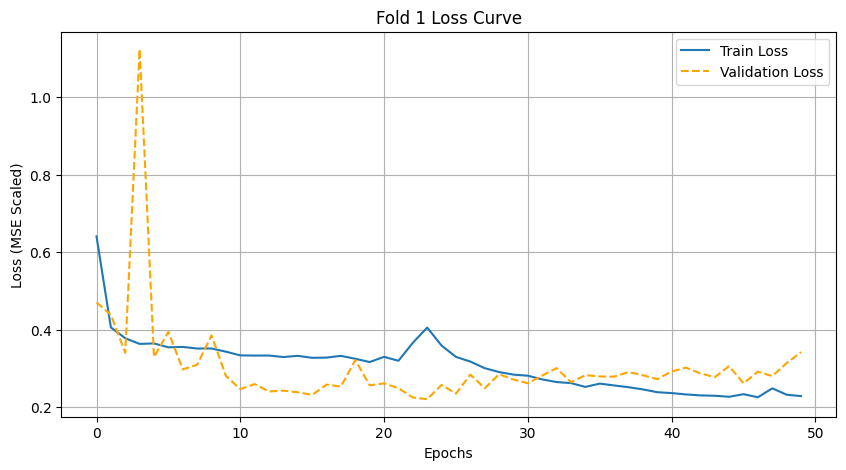

--- Preparing Fold 2/2 ---

=== Training Fold 2/2 ===
... Epoch 5 | Teacher Ratio: 0.40 | Train: 0.2386 | Val: 1.9569
... Epoch 10 | Teacher Ratio: 0.28 | Train: 0.2083 | Val: 1.6614
... Epoch 15 | Teacher Ratio: 0.15 | Train: 0.2058 | Val: 1.6585
... Epoch 20 | Teacher Ratio: 0.03 | Train: 0.2494 | Val: 1.8196
... Epoch 25 | Teacher Ratio: 0.00 | Train: 0.2121 | Val: 2.5139
... Epoch 30 | Teacher Ratio: 0.00 | Train: 0.1890 | Val: 2.2641
... Epoch 35 | Teacher Ratio: 0.00 | Train: 0.1723 | Val: 3.0270
... Epoch 40 | Teacher Ratio: 0.00 | Train: 0.1670 | Val: 2.9549
... Epoch 45 | Teacher Ratio: 0.00 | Train: 0.1648 | Val: 2.9369
... Epoch 50 | Teacher Ratio: 0.00 | Train: 0.1583 | Val: 2.5095
--> Fold 2 Finished: RMSE=0.50, MAE=0.28


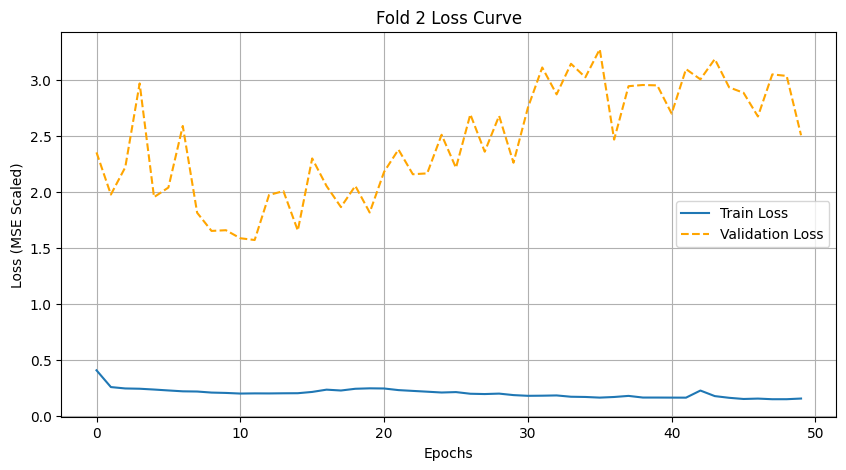


=== Final Cross-Validation Results ===
Average RMSE: 0.3588
Plotting Sample 0 (First day in test set)...


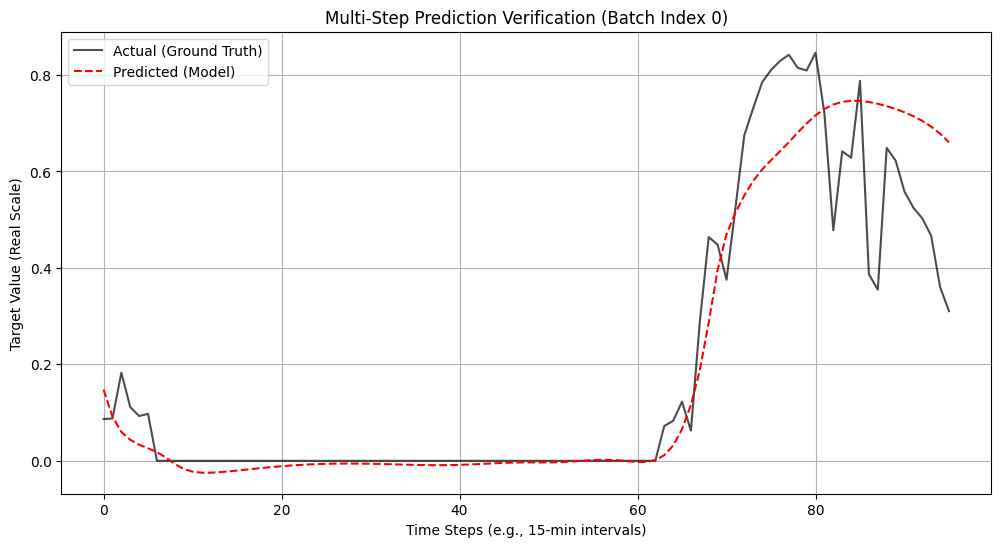

Plotting Sample 20 (Twentieth day in test set)...


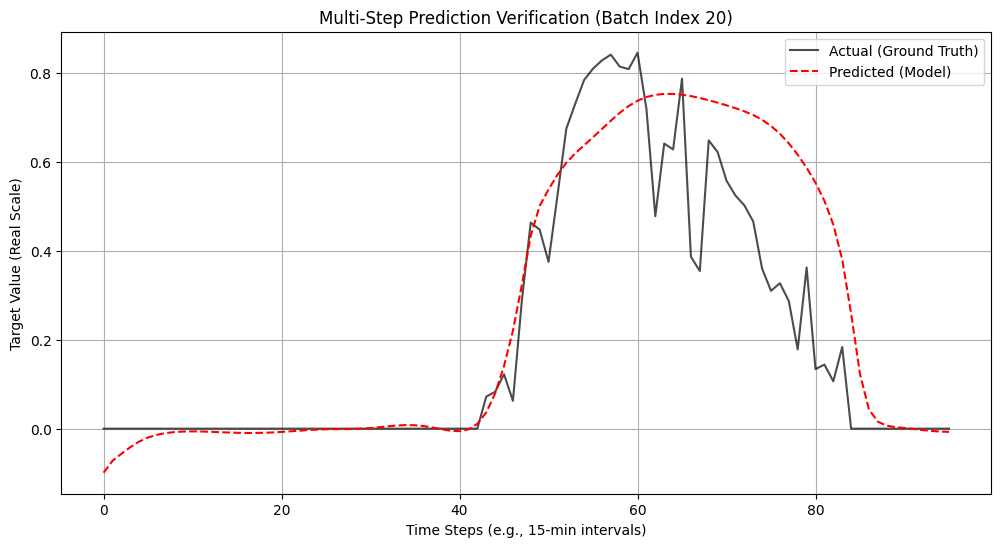

In [33]:
# 1. Run the Training
# This will automatically print Training/Val Loss plots for each fold as it runs
results, history = run_rolling_cv(df)

# 2. Visualize Predictions for a specific fold (e.g., the last one)
# We retrieve the saved model and loader from the results list
last_fold_data = results[-1] 

model_final = last_fold_data['model']
loader_final = last_fold_data['test_loader']
scaler_final = last_fold_data['scaler_y']

# 3. Check Prediction vs Ground Truth
# sample_idx=0 plots the FIRST window in the test set
# sample_idx=5 plots the FIFTH window, etc.
print("Plotting Sample 0 (First day in test set)...")
plot_prediction_sample(model_final, loader_final, scaler_final, sample_idx=0)

print("Plotting Sample 20 (Twentieth day in test set)...")
plot_prediction_sample(model_final, loader_final, scaler_final, sample_idx=20)

-------

In [ ]:
# We need these specific indices inside the Loss Function later
# Index 0: K_PV (Target History)
# Index 1: nwp_globalirrad (G)
# Index 2: nwp_temperature (Tamb)
INPUT_COLS = ['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
              'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
              'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
              'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV',
              'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
TARGET_COL = 'K_PV'

2. The Physics-Guided Loss Class

This class implements the Ross Model + Efficiency Physics logic. It is designed to be a drop-in replacement for nn.MSELoss.

In [14]:
import torch
import torch.nn as nn

class PhysicsGuidedLoss(nn.Module):
    """
    Physics-guided loss for K_PV (clear-sky index in [0, 1]) using:
      - Data loss (MSE)
      - Ross-based temperature proxy + efficiency derating (physics)
      - Boundary losses:
          * Night: G ~ 0 -> K_PV ~ 0
          * Capacity: K_PV <= 1
          * Nonnegativity: K_PV >= 0
    """
    def __init__(
        self,
        w_data: float = 1.0,
        w_phys: float = 0.2,
        w_night: float = 0.1,
        w_cap: float = 0.1,
        w_nonneg: float = 0.1,
        G_day_thr: float = 50.0,
        G_night_thr: float = 10.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        self.w_data = w_data
        self.w_phys = w_phys
        self.w_night = w_night
        self.w_cap = w_cap
        self.w_nonneg = w_nonneg

        # --- Ross / NOCT-style temperature model + efficiency ---
        # T_c = T_amb + k_ross * G
        # K_PV_phys ~ 1 - gamma * (T_c - T_ref)
        self.k_ross = nn.Parameter(torch.tensor(0.03))
        self.gamma  = nn.Parameter(torch.tensor(0.004))  # [°C / (W/m²)] ~ Ross coefficient
        self.T_ref = 25.0      # [°C] reference temperature (STC)

        # irradiance thresholds
        self.G_day_thr = G_day_thr     # daylight threshold for physics
        self.G_night_thr = G_night_thr # night threshold for boundary

    def forward(self, preds, targets, inputs):
        """
        preds:   [B, T, 1]  predicted K_PV
        targets: [B, T, 1]  true K_PV
        inputs:  [B, T, F]  future inputs (must contain G and T_amb):
                 F layout: ['K_PV', 'nwp_globalirrad', 'nwp_temperature', ...]
        """
        device = preds.device

        # -------------------------------
        # 1. Data loss (fit to labels)
        # -------------------------------
        preds_k = preds.squeeze(-1)      # [B, T]
        targets_k = targets.squeeze(-1)  # [B, T]
        loss_data = self.mse(preds_k, targets_k)

        # -------------------------------
        # 2. Extract physical inputs
        # -------------------------------
        G = inputs[:, :, 1]      # nwp_globalirrad [B, T]
        T_amb = inputs[:, :, 2]  # nwp_temperature [B, T] (°C)

        # -------------------------------
        # 3. Ross proxy temperature
        #    T_c ≈ T_amb + k_ross * G
        # -------------------------------
        T_c_proxy = T_amb + self.k_ross * G  # [B, T]

        # -------------------------------
        # 4. Physics baseline for K_PV
        #    K_phys = 1 - gamma * (T_c - T_ref)
        # -------------------------------
        K_phys = 1.0 - self.gamma * (T_c_proxy - self.T_ref)
        # Optional: clamp physics target to [0, 1] to avoid weird extremes
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # -------------------------------
        # 5. Physics loss (daylight only)
        # -------------------------------
        daylight_mask = G > self.G_day_thr  # [B, T], bool
        if daylight_mask.any():
            loss_phys = self.mse(
                preds_k[daylight_mask],
                K_phys[daylight_mask]
            )
        else:
            loss_phys = torch.zeros((), device=device)

        # -------------------------------
        # 6. Night boundary loss: G ~ 0 -> K ~ 0
        # -------------------------------
        night_mask = G < self.G_night_thr
        if night_mask.any():
            # Encourage K_PV ≈ 0 when there is no irradiance
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # -------------------------------
        # 7. Capacity boundary loss: K <= 1
        # -------------------------------
        # Penalize any prediction above 1
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        if torch.numel(over_cap) > 0:
            loss_cap = torch.mean(over_cap ** 2)
        else:
            loss_cap = torch.zeros((), device=device)

        # -------------------------------
        # 8. Non-negativity: K >= 0
        # -------------------------------
        under_zero = torch.clamp(-preds_k, min=0.0)
        if torch.numel(under_zero) > 0:
            loss_nonneg = torch.mean(under_zero ** 2)
        else:
            loss_nonneg = torch.zeros((), device=device)

        # -------------------------------
        # 9. Total loss
        # -------------------------------
        total_loss = (
            self.w_data   * loss_data   +
            self.w_phys   * loss_phys   +
            self.w_night  * loss_night  +
            self.w_cap    * loss_cap    +
            self.w_nonneg * loss_nonneg
        )

        return total_loss

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, current_ratio):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device).float()
        y_batch = y_batch.to(device).float()
        
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(X_batch, target=y_batch, teacher_forcing_ratio=current_ratio)
        
        # --- CHANGED: Pass Inputs to Loss ---
        loss = criterion(predictions, y_batch, X_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def evaluate_fold(model, loader, criterion, scaler_y):
    model.eval()
    total_loss = 0
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).float()
            
            predictions = model(X_batch, target=None, teacher_forcing_ratio=0.0)
            
            # --- CHANGED: Pass Inputs to Loss ---
            loss = criterion(predictions, y_batch, X_batch)
            total_loss += loss.item()
            
            # Store predictions
            all_preds.append(predictions.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())
            
    # --- Inverse Scaling & Metric Calculation ---
    # Concatenate all batches: [Total_Samples, Pred_Len, 1]
    preds_arr = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    
    # We need to flatten to [N_points, 1] to use scaler.inverse_transform
    # Then reshape back if we want per-step metrics, but for overall RMSE flattening is fine.
    
    # Reshape to 2D for scaler
    preds_flat = preds_arr.reshape(-1, 1)
    actuals_flat = actuals_arr.reshape(-1, 1)
    
    # Inverse Transform
    preds_real = scaler_y.inverse_transform(preds_flat)
    actuals_real = scaler_y.inverse_transform(actuals_flat)
    
    # Calculate Real-World RMSE
    rmse = np.sqrt(np.mean((preds_real - actuals_real)**2))
    mae = np.mean(np.abs(preds_real - actuals_real))
    
    # Quick Flatten Logic for completeness
    preds_arr = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    preds_flat = preds_arr.reshape(-1, 1)
    actuals_flat = actuals_arr.reshape(-1, 1)
    preds_real = scaler_y.inverse_transform(preds_flat)
    actuals_real = scaler_y.inverse_transform(actuals_flat)
    rmse = np.sqrt(np.mean((preds_real - actuals_real)**2))
    mae = np.mean(np.abs(preds_real - actuals_real))
    
    return total_loss / len(loader), rmse, mae, []

In [ ]:
# ---------------------------------------------------------
# 3. Main Execution Loop
# ---------------------------------------------------------

# Hyperparameters


N_SPLITS = 2
EPOCHS = 50
HIDDEN_DIM = 64
SEQ_LEN = 1344
PRED_LEN = 96
batch_size = 128



df = station07_df.copy()

import matplotlib.pyplot as plt
import numpy as np

def run_rolling_cv(df):
    results = []
    
    # Global history to store all folds
    # Structure: history[fold_num] = {'train': [], 'val': []}
    history = {} 

    # 1. Iterate through Folds
    folder_gen = prepare_rolling_folds(df, INPUT_COLS, TARGET_COL, n_splits=N_SPLITS, seq_len=SEQ_LEN, pred_len=PRED_LEN, batch_size=batch_size)
    
    for i, (train_loader, test_loader, scaler_X, scaler_y) in enumerate(folder_gen):
        fold_num = i + 1
        print(f"\n=== Training Fold {fold_num}/{N_SPLITS} ===")
        
        # Initialize history for this specific fold
        history[fold_num] = {'train': [], 'val': []}

        # 2. Instantiate FRESH Model
        input_dim = len(INPUT_COLS)

        
        # In run_rolling_cv:
        model = Seq2SeqLSTM(input_dim=len(INPUT_COLS),  # RevIN needs to know how many features
                                  hidden_dim=HIDDEN_DIM, 
                                  output_dim=1, 
                                  target_len=PRED_LEN).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = PhysicsGuidedLoss(
                w_data=1.0,
                w_phys=0.2,
                w_night=0.1,
                w_cap=0.1,
                w_nonneg=0.1
            ).to(device)

        # 3. Training Loop
        for epoch in range(EPOCHS):
            # --- TRAIN ---
            current_ratio = max(0.0, 0.5 - (epoch / (EPOCHS * 0.8)))
            t_loss = train_one_epoch(model, train_loader, optimizer, criterion, current_ratio)
            
            # --- VALIDATE (Inside the loop now!) ---
            # We ignore rmse/mae here for speed, just tracking loss for the plot
            v_loss, _, _, _ = evaluate_fold(model, test_loader, criterion, scaler_y)
            
            # --- STORE ---
            history[fold_num]['train'].append(t_loss)
            history[fold_num]['val'].append(v_loss)
            
            if (epoch+1) % 5 == 0:
                print(f"... Epoch {epoch+1} | Teacher Ratio: {current_ratio:.2f} | Train: {t_loss:.4f} | Val: {v_loss:.4f}")
        
        # 4. Final Evaluation (Get Real World Metrics for Reporting)
        _, real_rmse, real_mae, _ = evaluate_fold(model, test_loader, criterion, scaler_y)
        
        print(f"--> Fold {fold_num} Finished: RMSE={real_rmse:.2f}, MAE={real_mae:.2f}")
        
        results.append({
            'fold': fold_num,
            'rmse': real_rmse,
            'mae': real_mae,
            'model': model,       # Save model to plot predictions later
            'scaler_y': scaler_y, # Save scaler to inverse transform later
            'test_loader': test_loader
        })

        # 5. Plot Loss Curve for this Fold Immediately
        plot_loss_curve(history[fold_num]['train'], history[fold_num]['val'], fold_num)

    # 6. Average Results
    avg_rmse = np.mean([r['rmse'] for r in results])
    print(f"\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")
    
    return results, history

def plot_loss_curve(train_losses, val_losses, fold_num):
    """
    Plots the Training vs Validation Loss evolution for a specific fold.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--', color='orange')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE Scaled)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_prediction_sample(model, loader, scaler_y, sample_idx=0):
    """
    Plots a single sample sequence (e.g., 1 day / 96 steps) from the test set.
    Ensures multi-step verification by plotting the full sequence.
    """
    model.eval()
    
    # 1. Get a batch of data
    # We use iter() and next() to grab the first batch
    X_batch, y_batch = next(iter(loader))
    
    # Move to device
    X_batch = X_batch.to(device).float()
    y_batch = y_batch.to(device).float()

    # 2. Predict (No Teacher Forcing - Pure Autoregression)
    with torch.no_grad():
        preds = model(X_batch, target=None, teacher_forcing_ratio=0.0)

    # 3. Pick one sample from the batch (defined by sample_idx)
    # X_batch shape: [Batch, Seq_Len, Features]
    # preds shape:   [Batch, Pred_Len, 1]
    
    # We grab the specific sample sequence
    pred_seq_scaled = preds[sample_idx].cpu().numpy()
    actual_seq_scaled = y_batch[sample_idx].cpu().numpy()
    
    # 4. Inverse Transform
    # Scaler expects 2D array [n_samples, n_features]
    # pred_seq_scaled is [96, 1], which fits perfectly
    pred_seq_real = scaler_y.inverse_transform(pred_seq_scaled)
    actual_seq_real = scaler_y.inverse_transform(actual_seq_scaled)
    
    # 5. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq_real, label='Actual (Ground Truth)', color='black', alpha=0.7)
    plt.plot(pred_seq_real, label='Predicted (Model)', color='red', linestyle='--')
    
    plt.title(f'Multi-Step Prediction Verification (Batch Index {sample_idx})')
    plt.xlabel('Time Steps (e.g., 15-min intervals)')
    plt.ylabel('Target Value (Real Scale)')
    plt.legend()
    plt.grid(True)
    plt.show()



--- Preparing Fold 1/2 ---

=== Training Fold 1/2 ===
... Epoch 5 | Teacher Ratio: 0.25 | Train: 0.5136 | Val: 0.2840
... Epoch 10 | Teacher Ratio: 0.00 | Train: 0.6843 | Val: 0.2533
... Epoch 15 | Teacher Ratio: 0.00 | Train: 0.5663 | Val: 0.2728
... Epoch 20 | Teacher Ratio: 0.00 | Train: 0.4880 | Val: 0.2571
--> Fold 1 Finished: RMSE=0.17, MAE=0.11


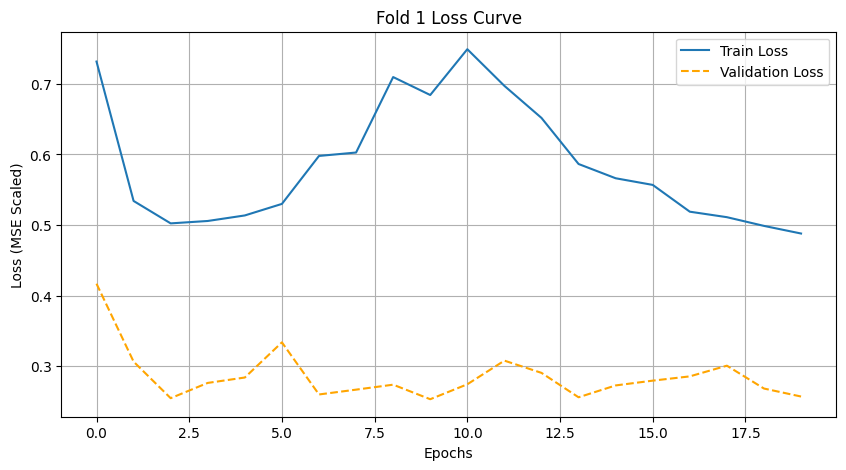

--- Preparing Fold 2/2 ---

=== Training Fold 2/2 ===
... Epoch 5 | Teacher Ratio: 0.25 | Train: 0.4077 | Val: 1.6754
... Epoch 10 | Teacher Ratio: 0.00 | Train: 0.4714 | Val: 1.5050
... Epoch 15 | Teacher Ratio: 0.00 | Train: 0.3773 | Val: 1.4461
... Epoch 20 | Teacher Ratio: 0.00 | Train: 0.3356 | Val: 1.5988
--> Fold 2 Finished: RMSE=0.38, MAE=0.20


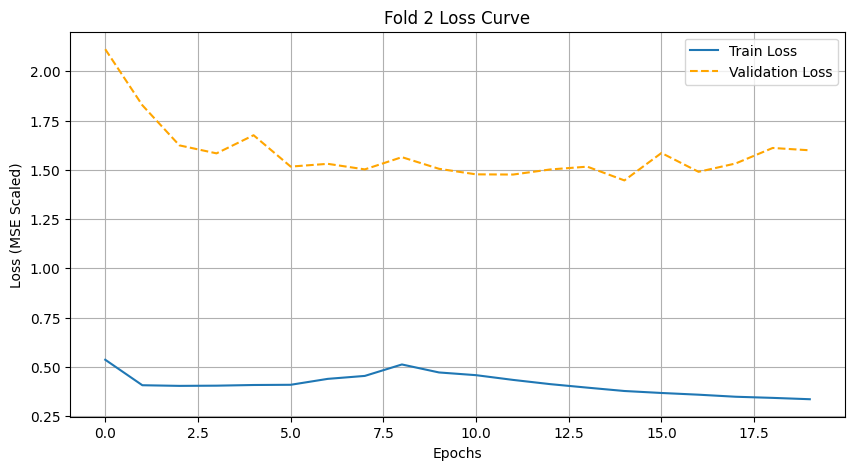


=== Final Cross-Validation Results ===
Average RMSE: 0.2732
Plotting Sample 0 (First day in test set)...


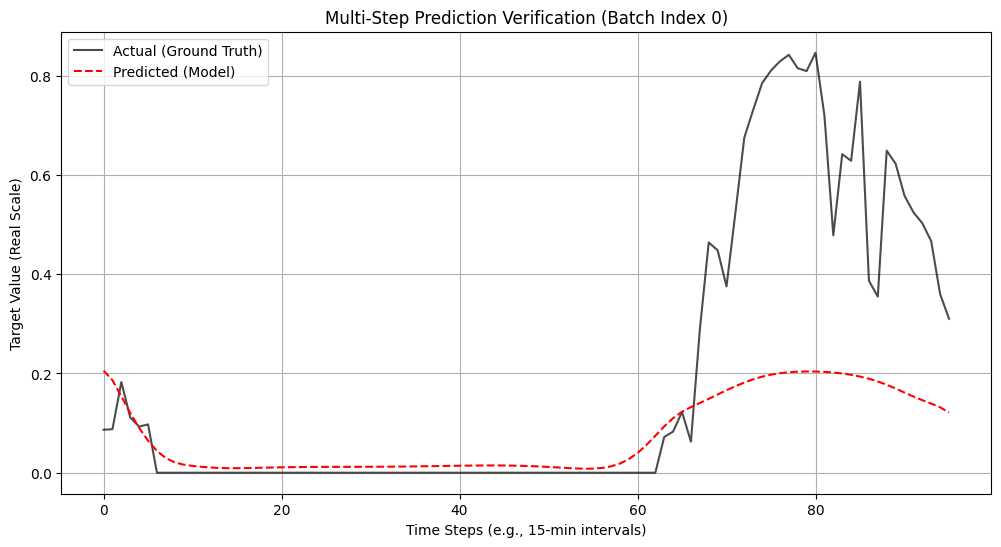

Plotting Sample 20 (Twentieth day in test set)...


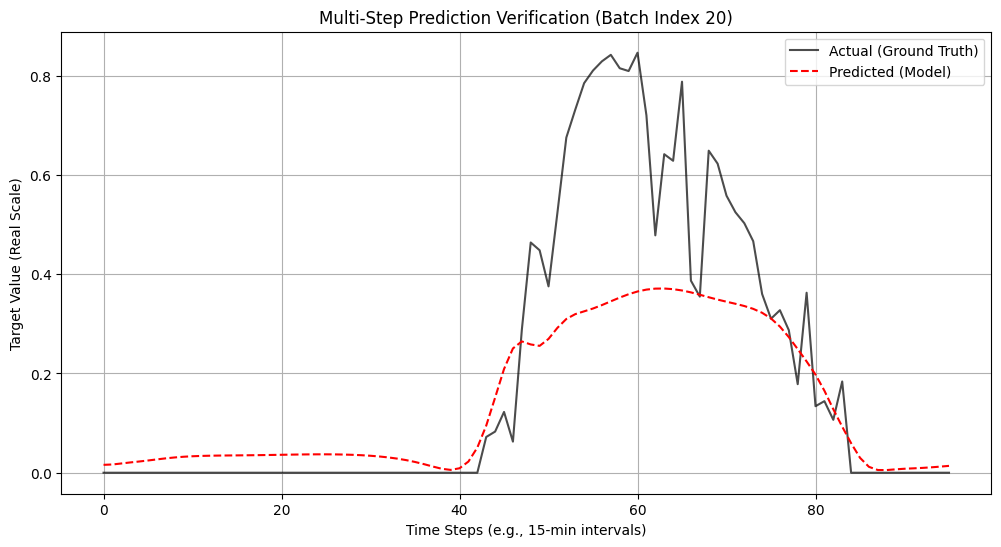

In [17]:
# 1. Run the Training
# This will automatically print Training/Val Loss plots for each fold as it runs
results, history = run_rolling_cv(df)

# 2. Visualize Predictions for a specific fold (e.g., the last one)
# We retrieve the saved model and loader from the results list
last_fold_data = results[-1] 

model_final = last_fold_data['model']
loader_final = last_fold_data['test_loader']
scaler_final = last_fold_data['scaler_y']

# 3. Check Prediction vs Ground Truth
# sample_idx=0 plots the FIRST window in the test set
# sample_idx=5 plots the FIFTH window, etc.
print("Plotting Sample 0 (First day in test set)...")
plot_prediction_sample(model_final, loader_final, scaler_final, sample_idx=0)

print("Plotting Sample 20 (Twentieth day in test set)...")
plot_prediction_sample(model_final, loader_final, scaler_final, sample_idx=20)

----